# SciPy Exercises XP GOLD



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal, poisson, expon
from scipy.stats import f_oneway, linregress
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## Exercise 1: Multivariate Normal Distribution


=== EXERCISE 1: Multivariate Normal Distribution ===
1. UNIVARIATE NORMAL DISTRIBUTION
Generated 1000 samples from univariate normal distribution
Mean: 0.019, Std: 0.979

2. MULTIVARIATE NORMAL DISTRIBUTION
Case 1 - Independent variables:
Mean vector: [0.02627068 0.05039977]
Covariance matrix:
[[0.94126868 0.03709456]
 [0.03709456 1.02265223]]

Case 2 - Correlated variables:
Mean vector: [2.06563722 3.03144617]
Covariance matrix:
[[2.05208227 1.51110096]
 [1.51110096 3.014045  ]]


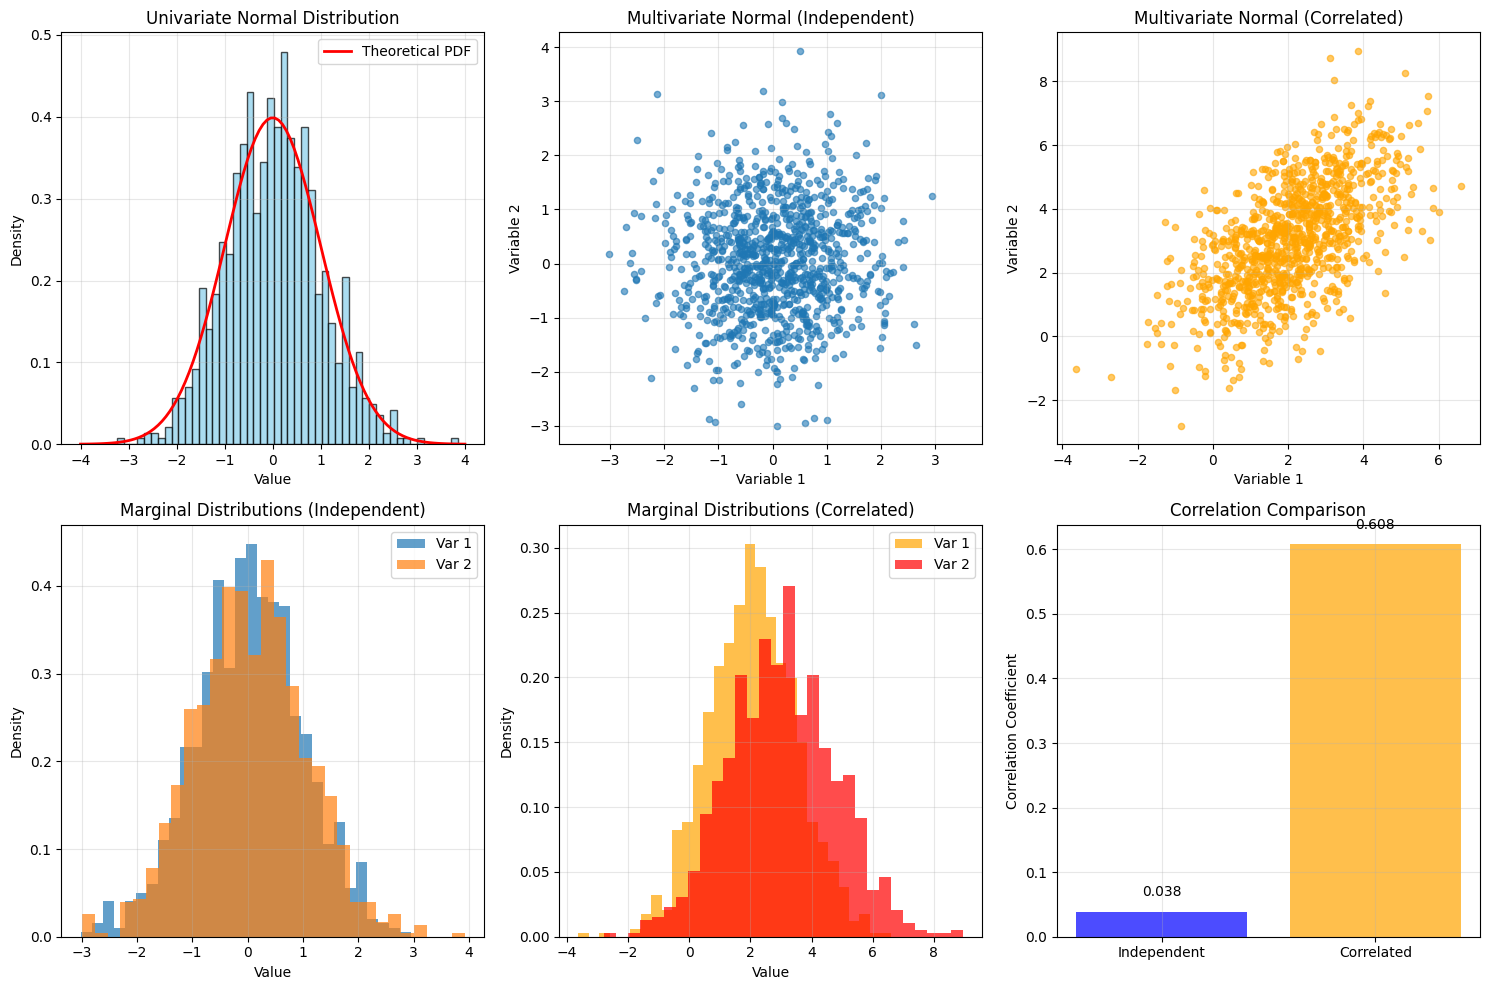


3. ANALYSIS AND DIFFERENCES
UNIVARIATE vs MULTIVARIATE DIFFERENCES:
- Univariate: Single variable, one-dimensional
- Multivariate: Multiple variables, multi-dimensional
- Univariate: Only variance matters
- Multivariate: Variance AND covariance/correlation matter

COVARIANCE MATRIX INTERPRETATION:
Independent case: Off-diagonal elements ≈ 0 (no correlation)
Correlated case: Off-diagonal elements ≠ 0 (positive correlation)

PRACTICAL IMPLICATIONS:
- Independent: Variables can be analyzed separately
- Correlated: Must consider joint behavior of variables
- Correlation affects the shape of the distribution ellipse


In [ ]:
# Exercise 1: Multivariate Normal Distribution
print("=== EXERCISE 1: Multivariate Normal Distribution ===")

# Set seed for reproducibility
np.random.seed(42)

# 1. Generate Univariate Normal Distribution
print("1. UNIVARIATE NORMAL DISTRIBUTION")
univariate_mean = 0
univariate_std = 1
sample_size = 1000

univariate_data = norm.rvs(loc=univariate_mean, scale=univariate_std, size=sample_size)

print(f"Generated {sample_size} samples from univariate normal distribution")
print(f"Mean: {np.mean(univariate_data):.3f}, Std: {np.std(univariate_data):.3f}")

# 2. Generate Multivariate Normal Distribution
print("\n2. MULTIVARIATE NORMAL DISTRIBUTION")

# Case 1: Independent variables (diagonal covariance)
mean_independent = [0, 0]
cov_independent = [[1, 0], [0, 1]]
multivariate_independent = multivariate_normal.rvs(mean=mean_independent, cov=cov_independent, size=sample_size)

print("Case 1 - Independent variables:")
print(f"Mean vector: {np.mean(multivariate_independent, axis=0)}")
print(f"Covariance matrix:\n{np.cov(multivariate_independent.T)}")

# Case 2: Correlated variables
mean_correlated = [2, 3]
cov_correlated = [[2, 1.5], [1.5, 3]]  # Positive correlation
multivariate_correlated = multivariate_normal.rvs(mean=mean_correlated, cov=cov_correlated, size=sample_size)

print("\nCase 2 - Correlated variables:")
print(f"Mean vector: {np.mean(multivariate_correlated, axis=0)}")
print(f"Covariance matrix:\n{np.cov(multivariate_correlated.T)}")

# 
plt.figure(figsize=(15, 10))

# Subplot 1: Univariate distribution histogram
plt.subplot(2, 3, 1)
plt.hist(univariate_data, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
x = np.linspace(-4, 4, 100)
plt.plot(x, norm.pdf(x, univariate_mean, univariate_std), 'r-', linewidth=2, label='Theoretical PDF')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Univariate Normal Distribution')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Multivariate independent - scatter plot
plt.subplot(2, 3, 2)
plt.scatter(multivariate_independent[:, 0], multivariate_independent[:, 1], alpha=0.6, s=20)
plt.xlabel('Variable 1')
plt.ylabel('Variable 2')
plt.title('Multivariate Normal (Independent)')
plt.grid(True, alpha=0.3)
plt.axis('equal')

# Subplot 3: Multivariate correlated - scatter plot
plt.subplot(2, 3, 3)
plt.scatter(multivariate_correlated[:, 0], multivariate_correlated[:, 1], alpha=0.6, s=20, color='orange')
plt.xlabel('Variable 1')
plt.ylabel('Variable 2')
plt.title('Multivariate Normal (Correlated)')
plt.grid(True, alpha=0.3)

# Subplot 4: Marginal distributions of independent case
plt.subplot(2, 3, 4)
plt.hist(multivariate_independent[:, 0], bins=30, alpha=0.7, label='Var 1', density=True)
plt.hist(multivariate_independent[:, 1], bins=30, alpha=0.7, label='Var 2', density=True)
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Marginal Distributions (Independent)')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 5: Marginal distributions of correlated case
plt.subplot(2, 3, 5)
plt.hist(multivariate_correlated[:, 0], bins=30, alpha=0.7, label='Var 1', density=True, color='orange')
plt.hist(multivariate_correlated[:, 1], bins=30, alpha=0.7, label='Var 2', density=True, color='red')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Marginal Distributions (Correlated)')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 6: Correlation comparison
plt.subplot(2, 3, 6)
correlations = [
    np.corrcoef(multivariate_independent.T)[0, 1],
    np.corrcoef(multivariate_correlated.T)[0, 1]
]
cases = ['Independent', 'Correlated']
bars = plt.bar(cases, correlations, color=['blue', 'orange'], alpha=0.7)
plt.ylabel('Correlation Coefficient')
plt.title('Correlation Comparison')
plt.grid(True, alpha=0.3)

for bar, corr in zip(bars, correlations):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{corr:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


print("\n3. ANALYSIS AND DIFFERENCES")
print("="*50)

print("UNIVARIATE vs MULTIVARIATE DIFFERENCES:")
print("- Univariate: Single variable, one-dimensional")
print("- Multivariate: Multiple variables, multi-dimensional")
print("- Univariate: Only variance matters")
print("- Multivariate: Variance AND covariance/correlation matter")

print("\nCOVARIANCE MATRIX INTERPRETATION:")
print("Independent case: Off-diagonal elements ≈ 0 (no correlation)")
print("Correlated case: Off-diagonal elements ≠ 0 (positive correlation)")

print("\nPRACTICAL IMPLICATIONS:")
print("- Independent: Variables can be analyzed separately")
print("- Correlated: Must consider joint behavior of variables")
print("- Correlation affects the shape of the distribution ellipse")



## Exercise 2: Advanced Probability Distributions



## Exercise 3: Statistical Hypothesis Testing



=== EXERCISE 3: ANOVA Test for Regional Sales Comparison ===
SALES DATA OVERVIEW:
Dataset shape: (30, 3)

Descriptive Statistics:
           Region 1      Region 2      Region 3
count     30.000000     30.000000     30.000000
mean   21328.569342  20986.673503  24331.395024
std     3300.985250   3199.834780   4825.219363
min    12341.030552  15067.212361  16368.586988
25%    19582.032142  18872.587748  20718.077838
50%    21216.133565  20756.356698  23771.306580
75%    24006.168879  22930.794080  27324.711968
max    26809.263872  28827.713883  34479.445880

DESCRIPTIVE STATISTICS BY REGION:
Region 1:
  Mean: $21,328.57
  Std Dev: $3,300.99
  Sample Size: 30
  Min: $12,341.03, Max: $26,809.26
Region 2:
  Mean: $20,986.67
  Std Dev: $3,199.83
  Sample Size: 30
  Min: $15,067.21, Max: $28,827.71
Region 3:
  Mean: $24,331.40
  Std Dev: $4,825.22
  Sample Size: 30
  Min: $16,368.59, Max: $34,479.45

ANOVA TEST RESULTS:
F-statistic: 6.8624
P-value: 0.001709

HYPOTHESIS TESTING:
Null Hypothesi

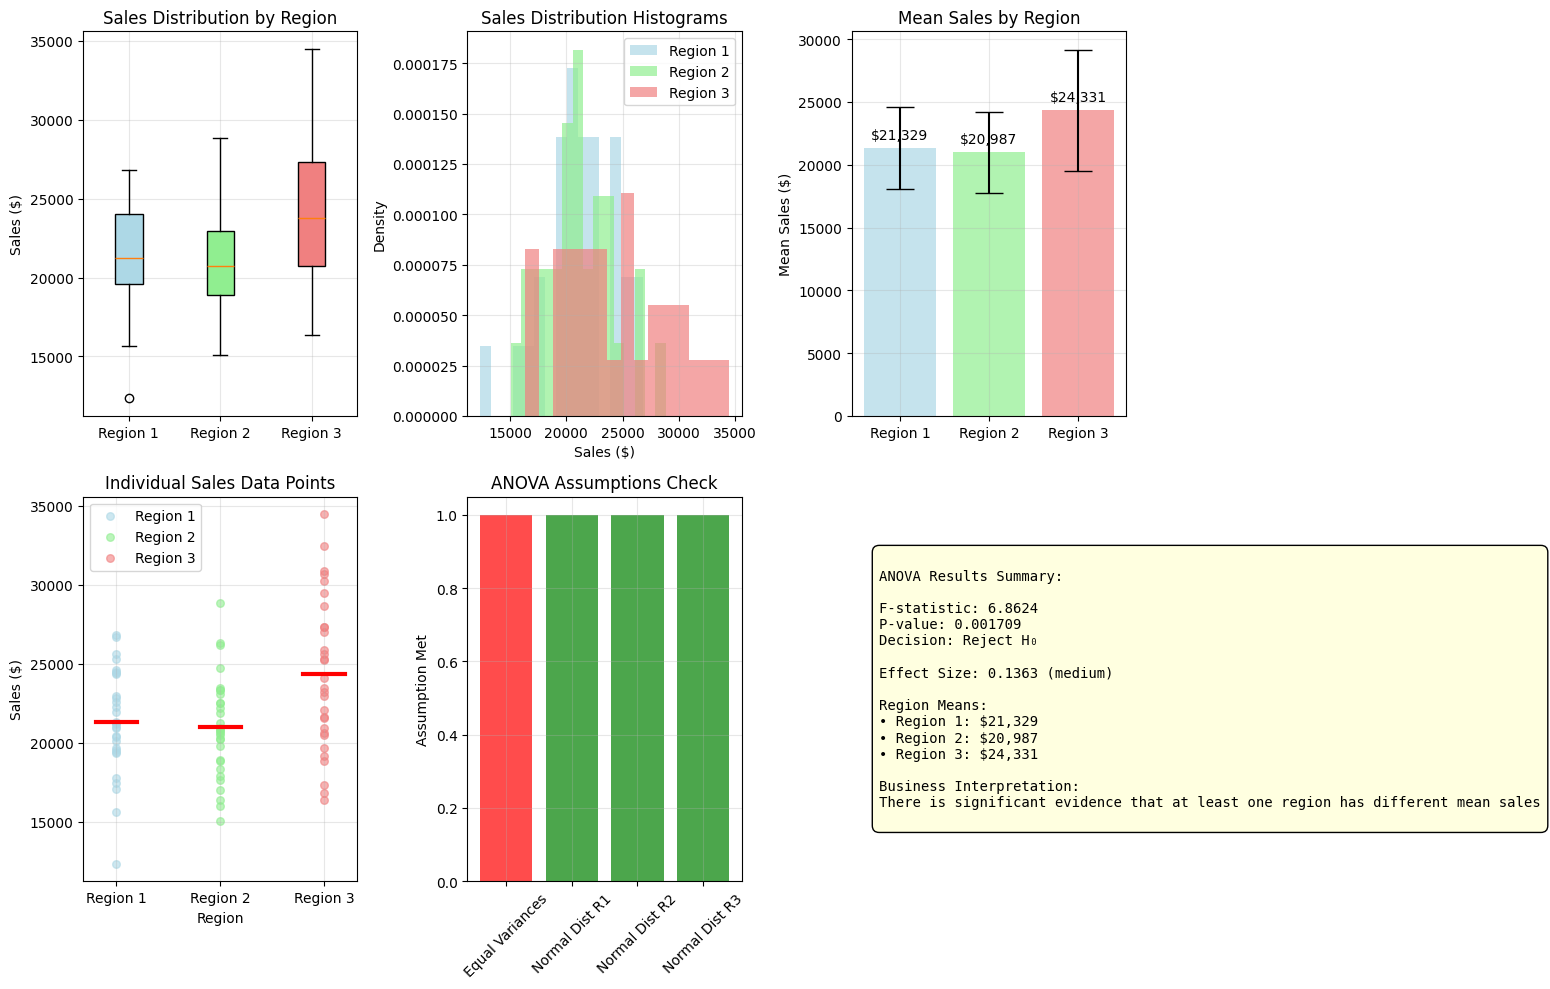


BUSINESS IMPLICATIONS:
- Regions have significantly different sales performance
- Management should investigate factors causing differences
- Best-performing regions can serve as models for improvement
- Resource allocation may need adjustment based on regional performance


In [6]:
# Exercise 3: Statistical Hypothesis Testing (ANOVA)
print("=== EXERCISE 3: ANOVA Test for Regional Sales Comparison ===")

# Generate sales data for different regions
np.random.seed(0)
region1 = np.random.normal(20000, 3000, 30)  # Region 1 sales
region2 = np.random.normal(22000, 3500, 30)  # Region 2 sales
region3 = np.random.normal(25000, 5000, 30)  # Region 3 sales

sales_data = pd.DataFrame({
    'Region 1': region1,
    'Region 2': region2,
    'Region 3': region3
})

print("SALES DATA OVERVIEW:")
print(f"Dataset shape: {sales_data.shape}")
print(f"\nDescriptive Statistics:")
print(sales_data.describe())

# Prepare data for ANOVA
print("\nDESCRIPTIVE STATISTICS BY REGION:")
regions = [region1, region2, region3]
region_names = ['Region 1', 'Region 2', 'Region 3']

for i, (region, name) in enumerate(zip(regions, region_names)):
    print(f"{name}:")
    print(f"  Mean: ${np.mean(region):,.2f}")
    print(f"  Std Dev: ${np.std(region, ddof=1):,.2f}")
    print(f"  Sample Size: {len(region)}")
    print(f"  Min: ${np.min(region):,.2f}, Max: ${np.max(region):,.2f}")

# Perform ANOVA test
f_statistic, p_value = f_oneway(region1, region2, region3)

print("\nANOVA TEST RESULTS:")
print(f"F-statistic: {f_statistic:.4f}")
print(f"P-value: {p_value:.6f}")

# Hypothesis testing interpretation
alpha = 0.05
print(f"\nHYPOTHESIS TESTING:")
print(f"Null Hypothesis (H₀): μ₁ = μ₂ = μ₃ (all regions have equal mean sales)")
print(f"Alternative Hypothesis (H₁): At least one region has different mean sales")
print(f"Significance level (α): {alpha}")

if p_value < alpha:
    decision = "Reject H₀"
    conclusion = "There is significant evidence that at least one region has different mean sales"
else:
    decision = "Fail to reject H₀"
    conclusion = "There is insufficient evidence to conclude that regions have different mean sales"

print(f"Decision: {decision}")
print(f"Conclusion: {conclusion}")

# Calculate effect size (eta-squared)
# Manual ANOVA calculations for educational purposes
all_sales = np.concatenate([region1, region2, region3])
overall_mean = np.mean(all_sales)
n_total = len(all_sales)

# Between-group sum of squares
group_means = [np.mean(region) for region in regions]
group_sizes = [len(region) for region in regions]
ssb = sum(n * (mean - overall_mean)**2 for n, mean in zip(group_sizes, group_means))

# Total sum of squares
sst = sum((x - overall_mean)**2 for x in all_sales)

# Effect size
eta_squared = ssb / sst

print(f"\nEFFECT SIZE:")
print(f"Eta-squared (η²): {eta_squared:.4f}")
print(f"Interpretation: {eta_squared*100:.1f}% of variance in sales is explained by region")

# Effect size interpretation
if eta_squared < 0.01:
    effect_size_interp = "negligible"
elif eta_squared < 0.06:
    effect_size_interp = "small"
elif eta_squared < 0.14:
    effect_size_interp = "medium"
else:
    effect_size_interp = "large"

print(f"Effect size magnitude: {effect_size_interp}")

# Visualization
plt.figure(figsize=(15, 10))

# Subplot 1: Box plots
plt.subplot(2, 3, 1)
box_plot = plt.boxplot([region1, region2, region3], labels=region_names, patch_artist=True)
colors = ['lightblue', 'lightgreen', 'lightcoral']
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
plt.ylabel('Sales ($)')
plt.title('Sales Distribution by Region')
plt.grid(True, alpha=0.3)

# Subplot 2: Histograms
plt.subplot(2, 3, 2)
for i, (region, name, color) in enumerate(zip(regions, region_names, colors)):
    plt.hist(region, bins=15, alpha=0.7, label=name, color=color, density=True)
plt.xlabel('Sales ($)')
plt.ylabel('Density')
plt.title('Sales Distribution Histograms')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 3: Means with error bars
plt.subplot(2, 3, 3)
means = [np.mean(region) for region in regions]
stds = [np.std(region, ddof=1) for region in regions]
bars = plt.bar(region_names, means, color=colors, alpha=0.7, yerr=stds, capsize=10)
plt.ylabel('Mean Sales ($)')
plt.title('Mean Sales by Region')
plt.grid(True, alpha=0.3)

# Add value labels
for bar, mean in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'${mean:,.0f}', ha='center', va='bottom')

# Subplot 4: Individual data points
plt.subplot(2, 3, 4)
for i, (region, name, color) in enumerate(zip(regions, region_names, colors)):
    x_pos = [i+1] * len(region)
    plt.scatter(x_pos, region, color=color, alpha=0.6, s=30, label=name)
    plt.plot([i+0.8, i+1.2], [np.mean(region), np.mean(region)], 'r-', linewidth=3)

plt.ylabel('Sales ($)')
plt.xlabel('Region')
plt.title('Individual Sales Data Points')
plt.xticks([1, 2, 3], region_names)
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 5: ANOVA assumptions check
from scipy.stats import levene, shapiro
plt.subplot(2, 3, 5)

# Test for equal variances (Levene's test)
levene_stat, levene_p = levene(region1, region2, region3)
equal_var = "Yes" if levene_p > 0.05 else "No"

# Test for normality (Shapiro-Wilk for each group)
normality_tests = []
for i, (region, name) in enumerate(zip(regions, region_names)):
    _, p_norm = shapiro(region)
    normality_tests.append("Yes" if p_norm > 0.05 else "No")

# Create assumption check visualization
assumptions = ['Equal Variances', 'Normal Dist R1', 'Normal Dist R2', 'Normal Dist R3']
results = [equal_var] + normality_tests
colors_assumption = ['green' if result == 'Yes' else 'red' for result in results]

plt.bar(range(len(assumptions)), [1]*len(assumptions), color=colors_assumption, alpha=0.7)
plt.xticks(range(len(assumptions)), assumptions, rotation=45)
plt.ylabel('Assumption Met')
plt.title('ANOVA Assumptions Check')
plt.grid(True, alpha=0.3)

# Subplot 6: Results summary
plt.subplot(2, 3, 6)
plt.axis('off')
summary_text = f"""
ANOVA Results Summary:

F-statistic: {f_statistic:.4f}
P-value: {p_value:.6f}
Decision: {decision}

Effect Size: {eta_squared:.4f} ({effect_size_interp})

Region Means:
• Region 1: ${np.mean(region1):,.0f}
• Region 2: ${np.mean(region2):,.0f}
• Region 3: ${np.mean(region3):,.0f}

Business Interpretation:
{conclusion}
"""

plt.text(0.1, 0.5, summary_text, fontsize=10, fontfamily='monospace',
         verticalalignment='center', bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow"))

plt.tight_layout()
plt.show()

print("\nBUSINESS IMPLICATIONS:")
if p_value < alpha:
    print("- Regions have significantly different sales performance")
    print("- Management should investigate factors causing differences")
    print("- Best-performing regions can serve as models for improvement")
    print("- Resource allocation may need adjustment based on regional performance")
else:
    print("- No significant differences found between regional sales")
    print("- Current strategy appears consistent across regions")
    print("- Focus on overall improvement rather than regional differences")



## Exercise 4: Linear Regression Analysis



=== EXERCISE 4: Linear Regression Analysis ===
DATASET OVERVIEW:
Dataset shape: (100, 2)

First 10 rows:
   Hours Studied  Test Score
0      27.440675   56.950190
1      35.759468   98.406936
2      30.138169   80.002046
3      27.244159   52.747961
4      21.182740   67.839372
5      32.294706   99.695656
6      21.879361   66.486197
7      44.588650  109.672377
8      48.183138  109.750319
9      19.172076   58.474707

Descriptive Statistics:
       Hours Studied  Test Score
count     100.000000  100.000000
mean       23.639692   61.022573
std        14.487701   37.401564
min         0.234774   -4.382055
25%        10.290158   25.760709
50%        23.374049   62.912175
75%        34.224163   90.162740
max        49.418692  141.158800

LINEAR REGRESSION RESULTS:
Slope (β₁): 2.4874
Intercept (β₀): 2.2215
Correlation coefficient (r): 0.9635
R-squared (r²): 0.9283
P-value: 0.000000
Standard error: 0.0698

REGRESSION EQUATION:
Test Score = 2.22 + 2.49 × Hours Studied

INTERPRETATION:
• Fo

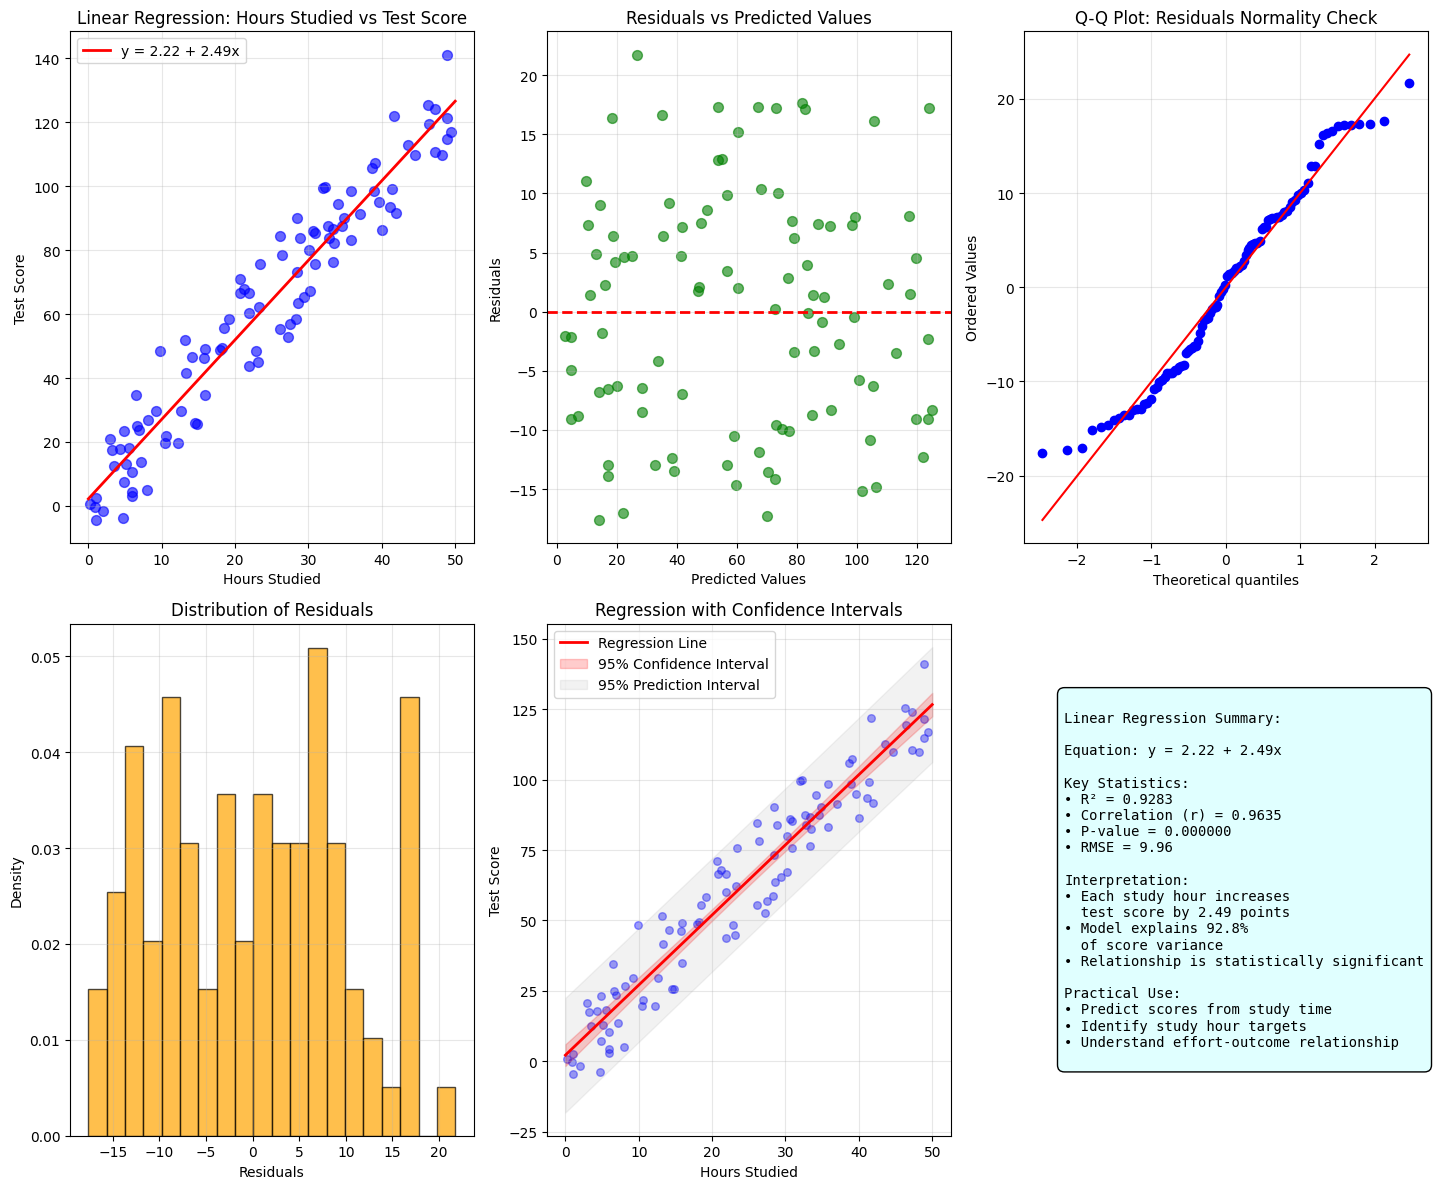


OUTLIER ANALYSIS:
Number of potential outliers (|standardized residual| > 2): 1
Outlier details:
  Point 64: 9.8 hours → 48.4 score (residual: 21.73)

MODEL ASSUMPTIONS CHECK:
1. Linearity: Visual inspection of scatter plot suggests linear relationship
2. Independence: Assumed based on data collection method
3. Homoscedasticity: Check residuals plot for constant variance
4. Normality of residuals: Check Q-Q plot and histogram

PRACTICAL RECOMMENDATIONS:
• Strong model - reliable for predictions within data range
• Use model for study time planning and goal setting
• Consider individual differences and other factors
• Validate model with new data before making important decisions


In [5]:
# Exercise 4: Linear Regression Analysis
print("=== EXERCISE 4: Linear Regression Analysis ===")

# Generate the dataset
np.random.seed(0)
X = np.random.rand(100) * 50  # Hours studied (0-50)
Y = 2.5 * X + np.random.randn(100) * 10  # Test scores with noise

linear_regression_data = pd.DataFrame({
    'Hours Studied': X,
    'Test Score': Y
})

print("DATASET OVERVIEW:")
print(f"Dataset shape: {linear_regression_data.shape}")
print(f"\nFirst 10 rows:")
print(linear_regression_data.head(10))

print(f"\nDescriptive Statistics:")
print(linear_regression_data.describe())

# Perform linear regression using SciPy
slope, intercept, r_value, p_value, std_err = linregress(X, Y)

print("\nLINEAR REGRESSION RESULTS:")
print(f"Slope (β₁): {slope:.4f}")
print(f"Intercept (β₀): {intercept:.4f}")
print(f"Correlation coefficient (r): {r_value:.4f}")
print(f"R-squared (r²): {r_value**2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Standard error: {std_err:.4f}")

# Regression equation
print(f"\nREGRESSION EQUATION:")
print(f"Test Score = {intercept:.2f} + {slope:.2f} × Hours Studied")

# Interpretation of results
print(f"\nINTERPRETATION:")
print(f"• For every additional hour studied, test score increases by {slope:.2f} points")
print(f"• When study hours = 0, predicted test score = {intercept:.2f}")
print(f"• {r_value**2*100:.1f}% of variance in test scores is explained by study hours")
print(f"• Correlation strength: {'Strong' if abs(r_value) > 0.7 else 'Moderate' if abs(r_value) > 0.5 else 'Weak'}")

# Statistical significance
alpha = 0.05
if p_value < alpha:
    significance = "Statistically significant"
    interpretation = "The relationship between study hours and test scores is significant"
else:
    significance = "Not statistically significant"
    interpretation = "The relationship between study hours and test scores is not significant"

print(f"• Statistical significance: {significance} (p = {p_value:.6f})")
print(f"• {interpretation}")

# Make predictions
print(f"\nPREDICTIONS:")
test_hours = [10, 20, 30, 40]
for hours in test_hours:
    predicted_score = intercept + slope * hours
    print(f"• {hours} hours studied → Predicted score: {predicted_score:.1f}")

# Calculate confidence intervals for predictions
from scipy.stats import t
n = len(X)
dof = n - 2  # degrees of freedom

# Standard error of prediction
def prediction_std_err(x_pred, X, Y, slope, intercept):
    x_mean = np.mean(X)
    sxx = np.sum((X - x_mean)**2)
    residuals = Y - (intercept + slope * X)
    mse = np.sum(residuals**2) / (n - 2)
    
    se_pred = np.sqrt(mse * (1 + 1/n + (x_pred - x_mean)**2 / sxx))
    return se_pred

# Calculate residuals and model diagnostics
Y_pred = intercept + slope * X
residuals = Y - Y_pred
mse = np.mean(residuals**2)
rmse = np.sqrt(mse)

print(f"\nMODEL DIAGNOSTICS:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {np.mean(np.abs(residuals)):.4f}")

# Visualization
plt.figure(figsize=(15, 12))

# Subplot 1: Scatter plot with regression line
plt.subplot(2, 3, 1)
plt.scatter(X, Y, alpha=0.6, color='blue', s=50)
x_line = np.linspace(0, 50, 100)
y_line = intercept + slope * x_line
plt.plot(x_line, y_line, 'r-', linewidth=2, label=f'y = {intercept:.2f} + {slope:.2f}x')
plt.xlabel('Hours Studied')
plt.ylabel('Test Score')
plt.title('Linear Regression: Hours Studied vs Test Score')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Residuals plot
plt.subplot(2, 3, 2)
plt.scatter(Y_pred, residuals, alpha=0.6, color='green', s=50)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.grid(True, alpha=0.3)

# Subplot 3: Q-Q plot for residuals normality
from scipy.stats import probplot
plt.subplot(2, 3, 3)
probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot: Residuals Normality Check')
plt.grid(True, alpha=0.3)

# Subplot 4: Histogram of residuals
plt.subplot(2, 3, 4)
plt.hist(residuals, bins=20, density=True, alpha=0.7, color='orange', edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Density')
plt.title('Distribution of Residuals')
plt.grid(True, alpha=0.3)

# Subplot 5: Confidence and prediction intervals
plt.subplot(2, 3, 5)
plt.scatter(X, Y, alpha=0.4, color='blue', s=30)
plt.plot(x_line, y_line, 'r-', linewidth=2, label='Regression Line')

# Calculate confidence intervals
t_critical = t.ppf(0.975, dof)
x_mean = np.mean(X)
sxx = np.sum((X - x_mean)**2)
residuals_full = Y - (intercept + slope * X)
mse_full = np.sum(residuals_full**2) / dof

conf_interval = []
pred_interval = []

for x_val in x_line:
    # Confidence interval for mean response
    se_conf = np.sqrt(mse_full * (1/n + (x_val - x_mean)**2 / sxx))
    margin_conf = t_critical * se_conf
    
    # Prediction interval for individual response
    se_pred = np.sqrt(mse_full * (1 + 1/n + (x_val - x_mean)**2 / sxx))
    margin_pred = t_critical * se_pred
    
    y_val = intercept + slope * x_val
    conf_interval.append([y_val - margin_conf, y_val + margin_conf])
    pred_interval.append([y_val - margin_pred, y_val + margin_pred])

conf_interval = np.array(conf_interval)
pred_interval = np.array(pred_interval)

plt.fill_between(x_line, conf_interval[:, 0], conf_interval[:, 1], 
                alpha=0.2, color='red', label='95% Confidence Interval')
plt.fill_between(x_line, pred_interval[:, 0], pred_interval[:, 1], 
                alpha=0.1, color='gray', label='95% Prediction Interval')

plt.xlabel('Hours Studied')
plt.ylabel('Test Score')
plt.title('Regression with Confidence Intervals')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 6: Results summary
plt.subplot(2, 3, 6)
plt.axis('off')
summary_text = f"""
Linear Regression Summary:

Equation: y = {intercept:.2f} + {slope:.2f}x

Key Statistics:
• R² = {r_value**2:.4f}
• Correlation (r) = {r_value:.4f}
• P-value = {p_value:.6f}
• RMSE = {rmse:.2f}

Interpretation:
• Each study hour increases 
  test score by {slope:.2f} points
• Model explains {r_value**2*100:.1f}% 
  of score variance
• Relationship is {significance.lower()}

Practical Use:
• Predict scores from study time
• Identify study hour targets
• Understand effort-outcome relationship
"""

plt.text(0.1, 0.5, summary_text, fontsize=10, fontfamily='monospace',
         verticalalignment='center', bbox=dict(boxstyle="round,pad=0.5", facecolor="lightcyan"))

plt.tight_layout()
plt.show()

# Additional analysis: Outlier detection
print(f"\nOUTLIER ANALYSIS:")
# Calculate standardized residuals
standardized_residuals = residuals / np.std(residuals)
outliers = np.abs(standardized_residuals) > 2

print(f"Number of potential outliers (|standardized residual| > 2): {np.sum(outliers)}")
if np.sum(outliers) > 0:
    outlier_indices = np.where(outliers)[0]
    print("Outlier details:")
    for idx in outlier_indices:
        print(f"  Point {idx}: {X[idx]:.1f} hours → {Y[idx]:.1f} score (residual: {residuals[idx]:.2f})")

# Model assumptions check
print(f"\nMODEL ASSUMPTIONS CHECK:")
print("1. Linearity: Visual inspection of scatter plot suggests linear relationship")
print("2. Independence: Assumed based on data collection method")
print("3. Homoscedasticity: Check residuals plot for constant variance")
print("4. Normality of residuals: Check Q-Q plot and histogram")

# Practical recommendations
print(f"\nPRACTICAL RECOMMENDATIONS:")
if r_value**2 > 0.7:
    print("• Strong model - reliable for predictions within data range")
elif r_value**2 > 0.5:
    print("• Moderate model - useful but consider additional variables")
else:
    print("• Weak model - explore other factors affecting test scores")

print("• Use model for study time planning and goal setting")
print("• Consider individual differences and other factors")
print("• Validate model with new data before making important decisions")

